In [1]:
import numpy as np
import pandas as pd
import pickle

import importlib

#### Load Test Data

In [2]:
real_norm = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_real_norm.npy")
real_asmi = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_real_asmi.npy")
real_imi = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_real_imi.npy")

real_norm_label  = "NORM"
real_asmi_label = "ASMI"
real_imi_label = "IMI"

In [15]:
asmi_fnorm = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_fake_asmi_from_norm.npy")
asmi_fimi = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_fake_asmi_from_imi.npy")

imi_fnorm = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_fake_imi_from_norm.npy")
imi_fasmi = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_fake_imi_from_asmi.npy")

norm_fasmi = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_fake_norm_from_asmi.npy")
norm_fimi = np.load("/home/ECG_Quality_Evaluation/TestData/TEST_fake_norm_from_imi.npy")

asmi_fnorm_label = "ASMI_from_NORM"
asmi_fimi_label = "ASMI_from_IMI"

imi_fnorm_label = "IMI_from_NORM"
imi_fasmi_label = "IMI_from_ASMI"

norm_fasmi_label = "NORM_from_ASMI"
norm_fimi_label = "NORM_from_IMI"

print(norm_fasmi.shape, norm_fimi.shape, asmi_fnorm.shape, asmi_fimi.shape, imi_fnorm.shape, imi_fasmi.shape)

(10, 40, 12) (10, 40, 12) (10, 40, 12) (10, 40, 12) (10, 40, 12) (10, 40, 12)


### Test DataClass

In [4]:
import utils
importlib.reload(utils)
from utils import make_data_class

In [5]:
real_labels_list = ["ASMI", "ASMI", "IMI", "IMI", "NORM",  "NORM"]
real_data_list = [real_asmi, real_asmi, real_imi, real_imi, real_norm, real_norm]
gen_labels_list = ["asmi_fimi","asmi_fnorm","imi_fasmi", "imi_fnorm", "norm_fasmi",  "norm_fimi",  ]
gen_data_list = [asmi_fimi, asmi_fnorm, imi_fasmi, imi_fnorm, norm_fasmi, norm_fimi]

ecg_datasets = make_data_class(real_labels_list, real_data_list, gen_labels_list, gen_data_list)

### TEST Ecg BANDS

In [6]:
import plot_ecg_bands
importlib.reload(plot_ecg_bands)
from plot_ecg_bands import plot_bands_datasets

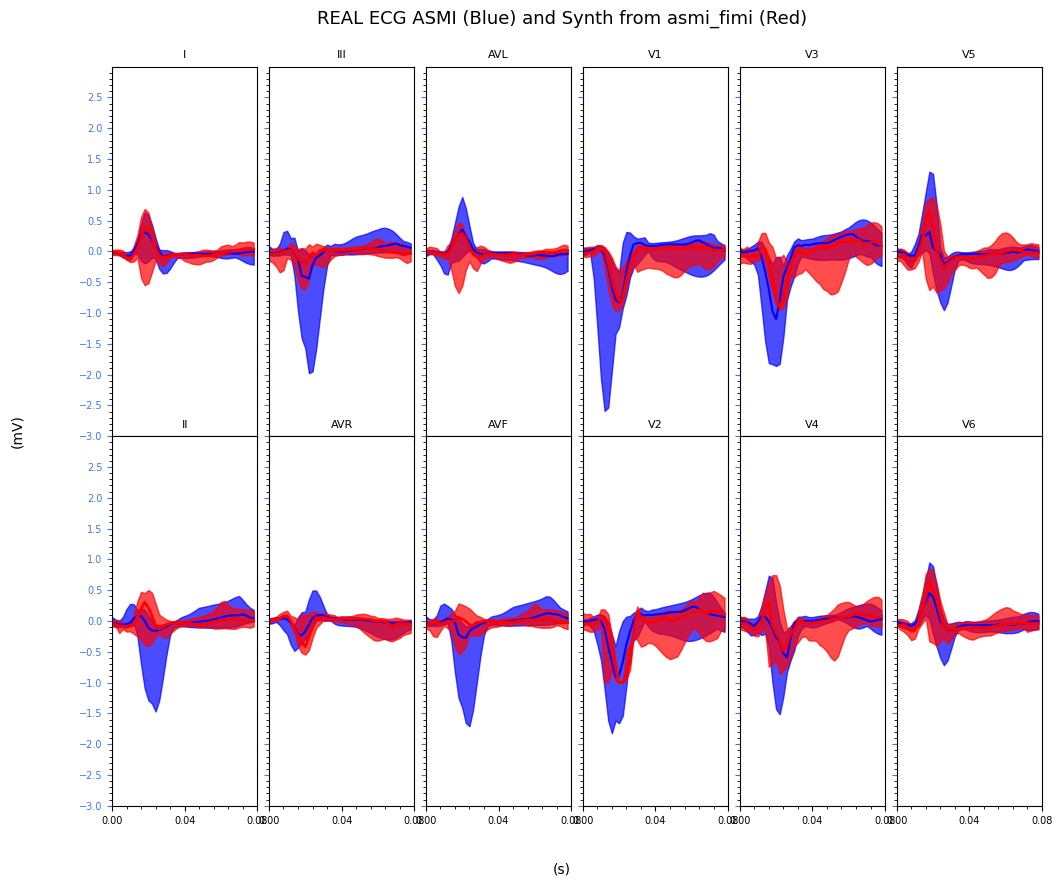

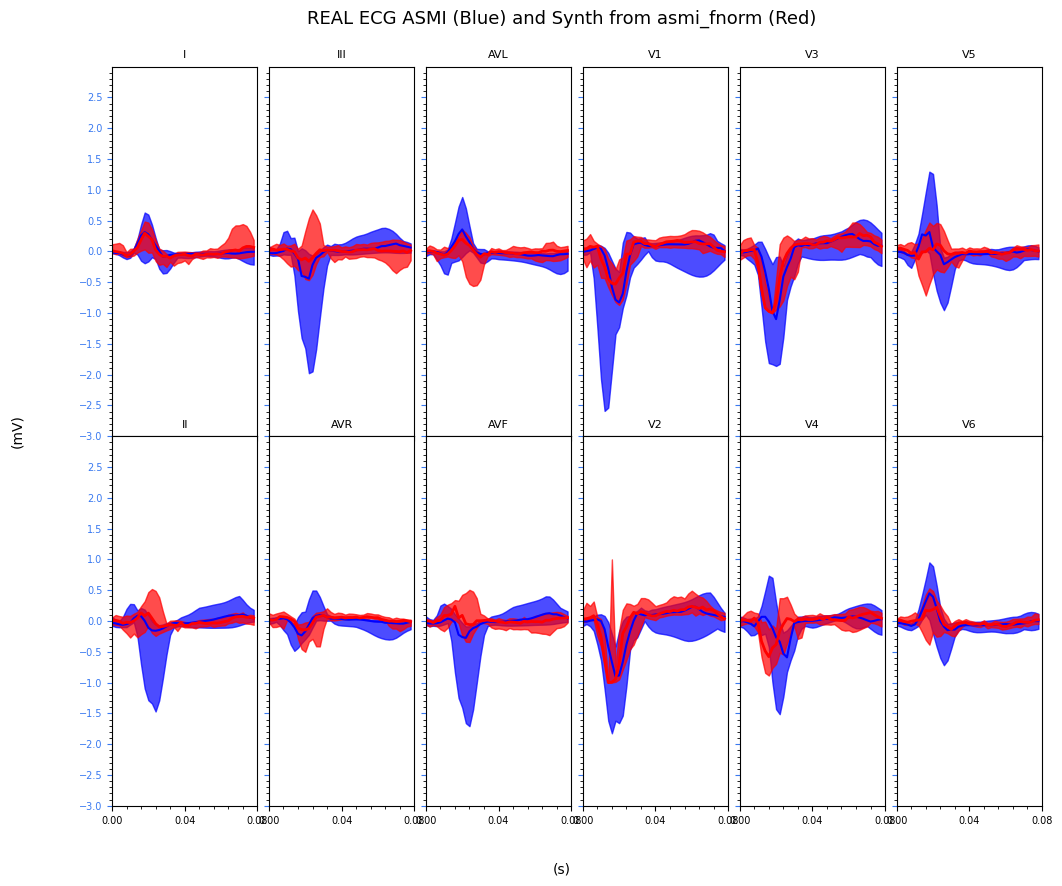

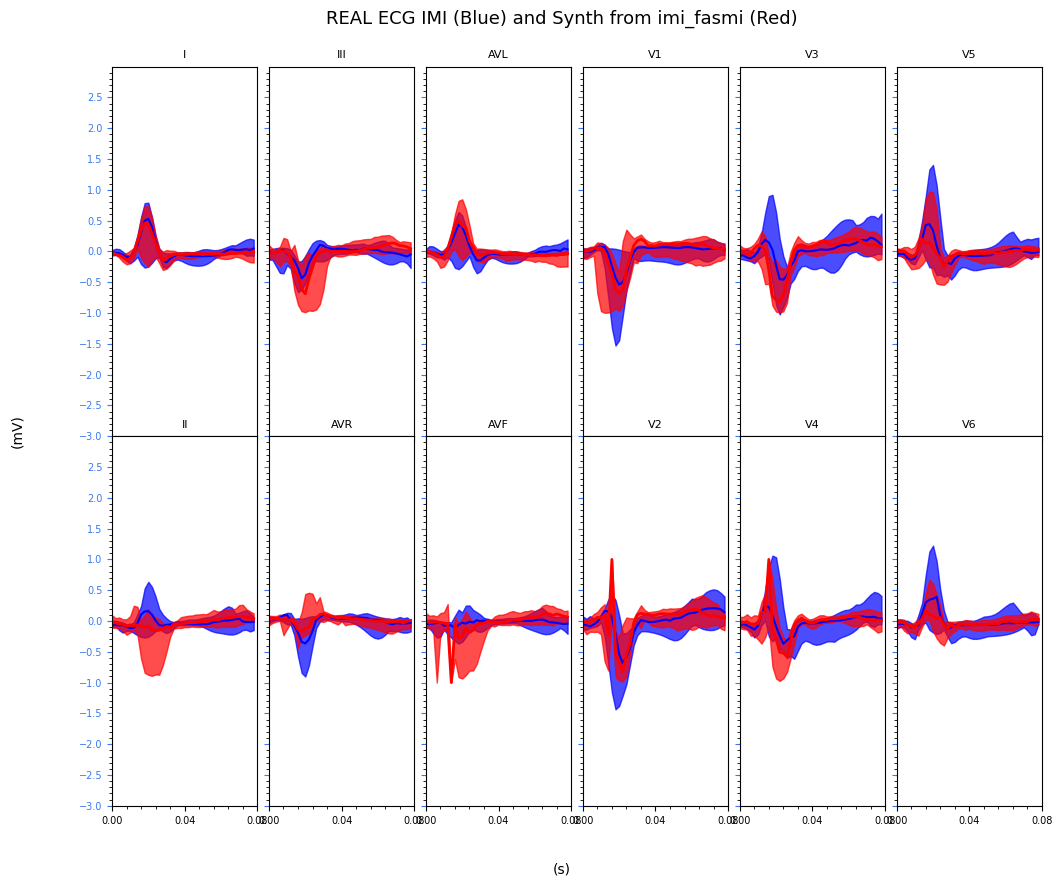

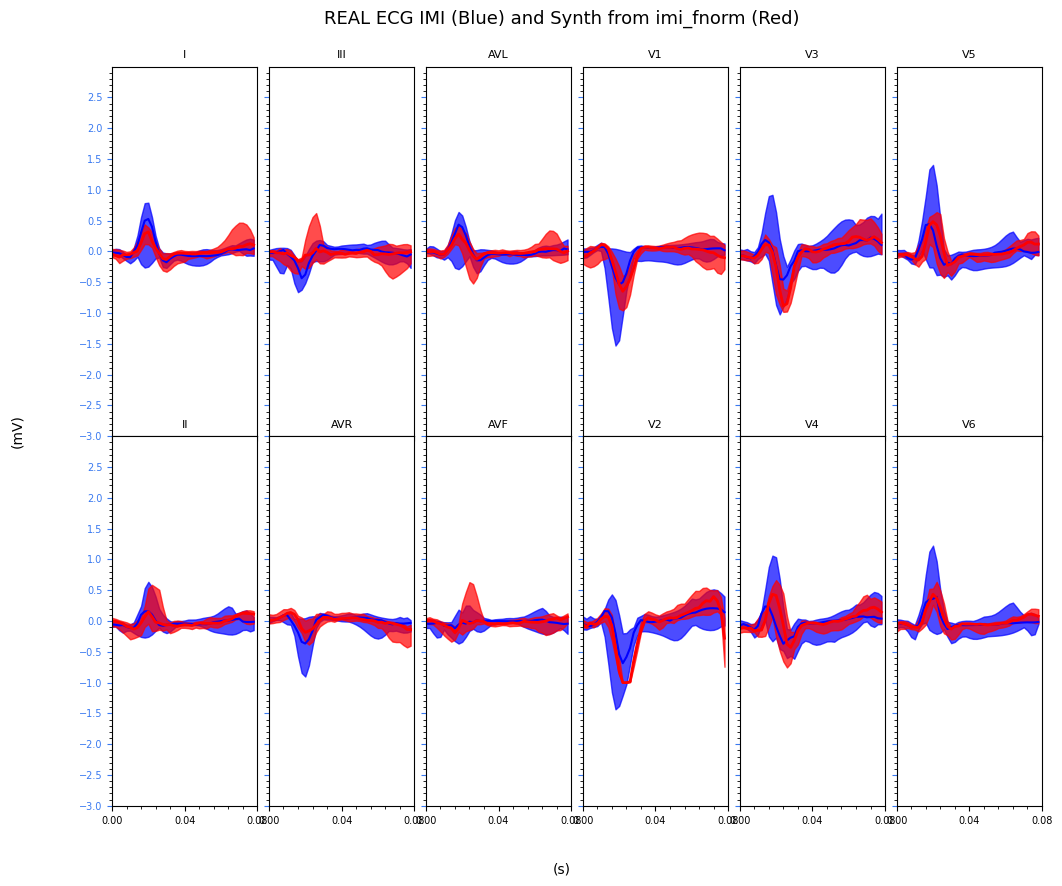

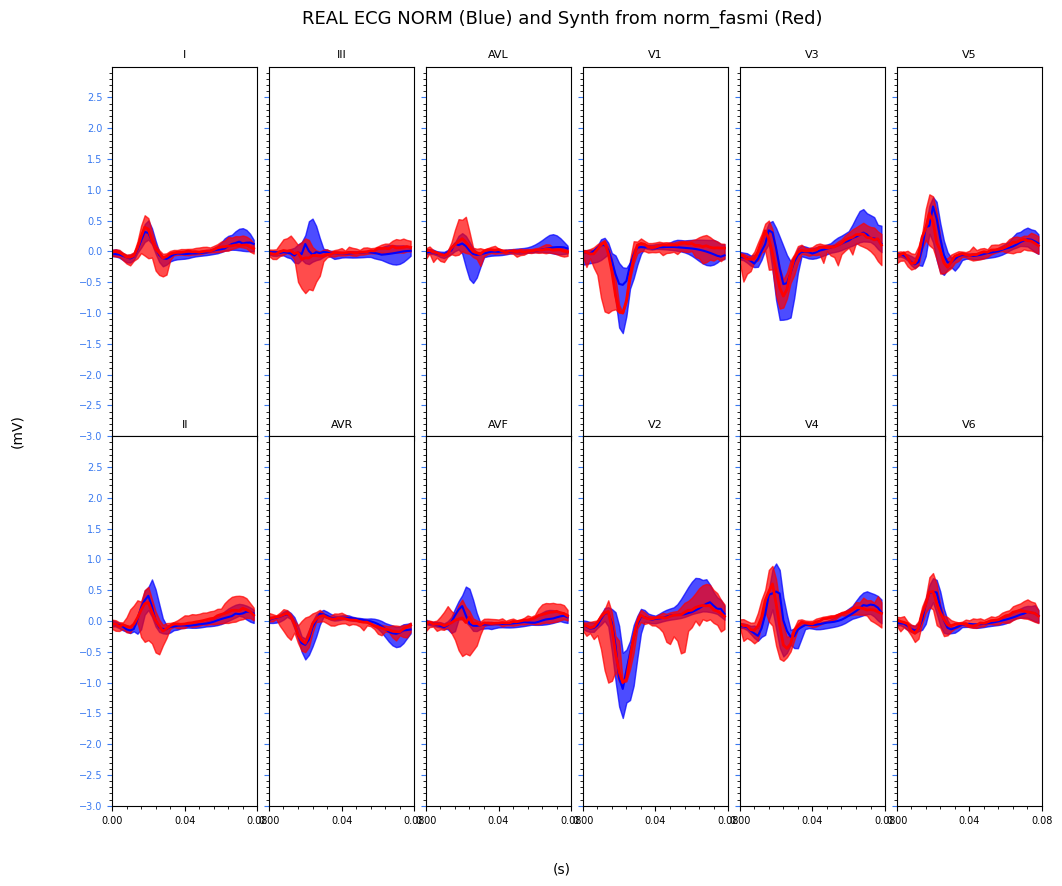

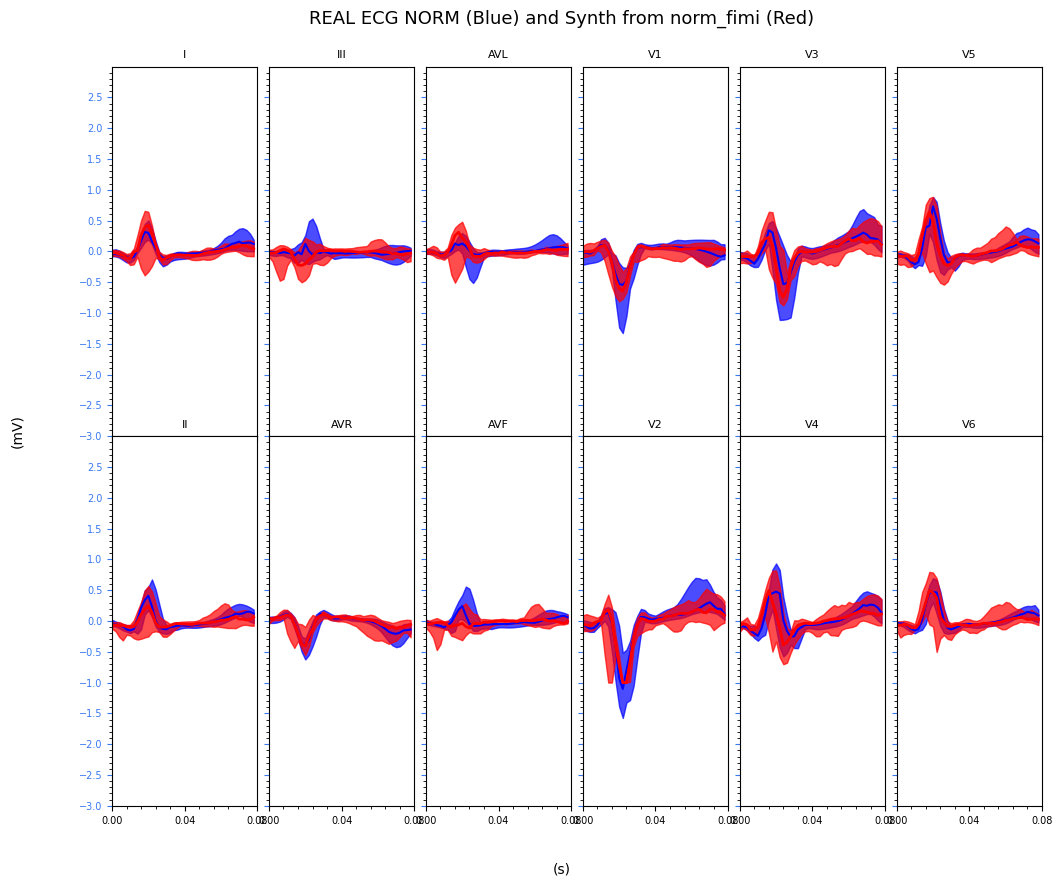

In [7]:
save_bands_folder = None #"/home/ECG_Quality_Evaluation/Test_Figs"
sampling_freq = 500
plot_bands_datasets(ecg_datasets, save_figs_folder = save_bands_folder, 
                    bands = True, ecg_sampling_frequency = sampling_freq, 
                    show_avg_ecg = True, grid_on = False)

### Test UMAP Plots

In [8]:
import plot_umap_maps
importlib.reload(plot_umap_maps)
from plot_umap_maps import plot_UMAP_datasets, make_2d_UMAP_datapairs

/home/ECG_Quality_Evaluation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
umap_ecg_datapairs = make_2d_UMAP_datapairs(ecg_datasets, random_state = 42)
plot_UMAP_datasets(umap_ecg_datapairs, title_on = True, save_path = None, save_single = None )

## Test GAN-Train-Test scores

In [11]:
import GAN_train_test
importlib.reload(GAN_train_test)
from GAN_train_test import compute_gan_train_test_scores

In [12]:
train_config = {
    "device": "cuda",      # or "cpu"
    "test_size": 0.2,
    "random_state": 42,
    "batch_size": 32,
    "epochs": 15,
    "lr": 1e-3,

    "aux_cls_features": [8,16,32,64],
    "aux_cls_kernels": [5, 5, 3, 3],
    "aux_cls_strides": [1, 2, 2, 1],
    "aux_cls_padding":  [2, 2, 1, 1],
    "n_classes": 3,
}

In [ ]:
# Train AUX lcassifier, this can be anything really. As long as it's trainable via CE
import GAN_train_test_classifier
importlib.reload(GAN_train_test_classifier)
from GAN_train_test_classifier import ECG_Classifier

gan_train_model = ECG_Classifier(features=train_config["aux_cls_features"],
                                 kernels=train_config["aux_cls_kernels"],
                                 strides=train_config["aux_cls_strides"],
                                 padding=train_config["aux_cls_padding"],
                                 n_classes=train_config["n_classes"],
                                 name = "GAN-train")

gan_test_model = ECG_Classifier(features=train_config["aux_cls_features"],
                                 kernels=train_config["aux_cls_kernels"],
                                 strides=train_config["aux_cls_strides"],
                                 padding=train_config["aux_cls_padding"],
                                 n_classes=train_config["n_classes"],
                                 name = "GAN-test")


/home/ECG_Quality_Evaluation/.venv/lib/python3.10/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Encoding labels dictionary:  {0: 'ASMI', 1: 'IMI', 2: 'NORM'}
GAN train model training on FAKE DATA...


Train AUX Model: 100%|██████████| 15/15 [00:00<00:00, 15.29epoch/s]




GAN test model training on REAL DATA...


Train AUX Model: 100%|██████████| 15/15 [00:00<00:00, 83.37epoch/s]


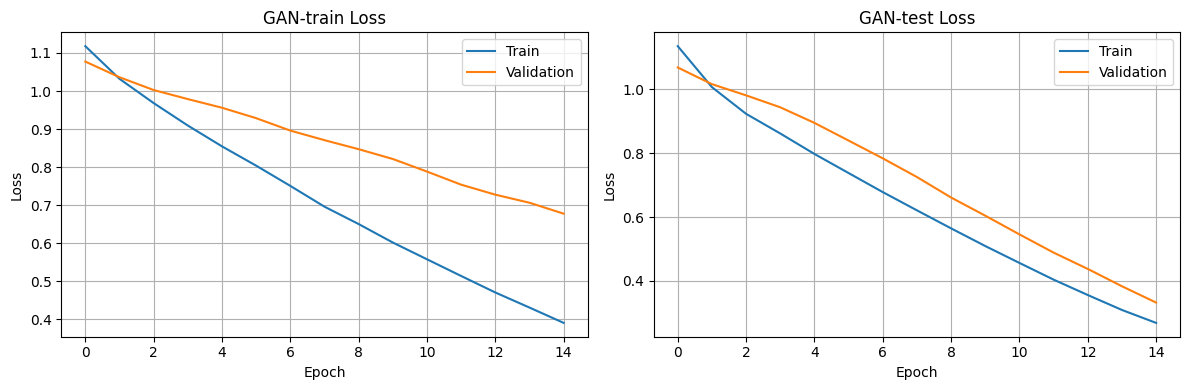

{'GAN-test': {'baseline': 0.5833333333333334, 'score': 0.3333333333333333},
 'GAN-train': {'baseline': 0.3333333333333333, 'score': 0.5833333333333334}}


In [ ]:
save_folder = "/home/ECG_Quality_Evaluation/Test_Figs"

compute_gan_train_test_scores(gan_train_model, gan_test_model, ecg_datasets, train_config, 
                                  plot_loss_hist = True, save_folder = save_folder)

### Test ST-segment Computation

In [19]:
import ST_segments_evaluation
importlib.reload(ST_segments_evaluation)

from ST_segments_evaluation import plot_multiple_st_radar

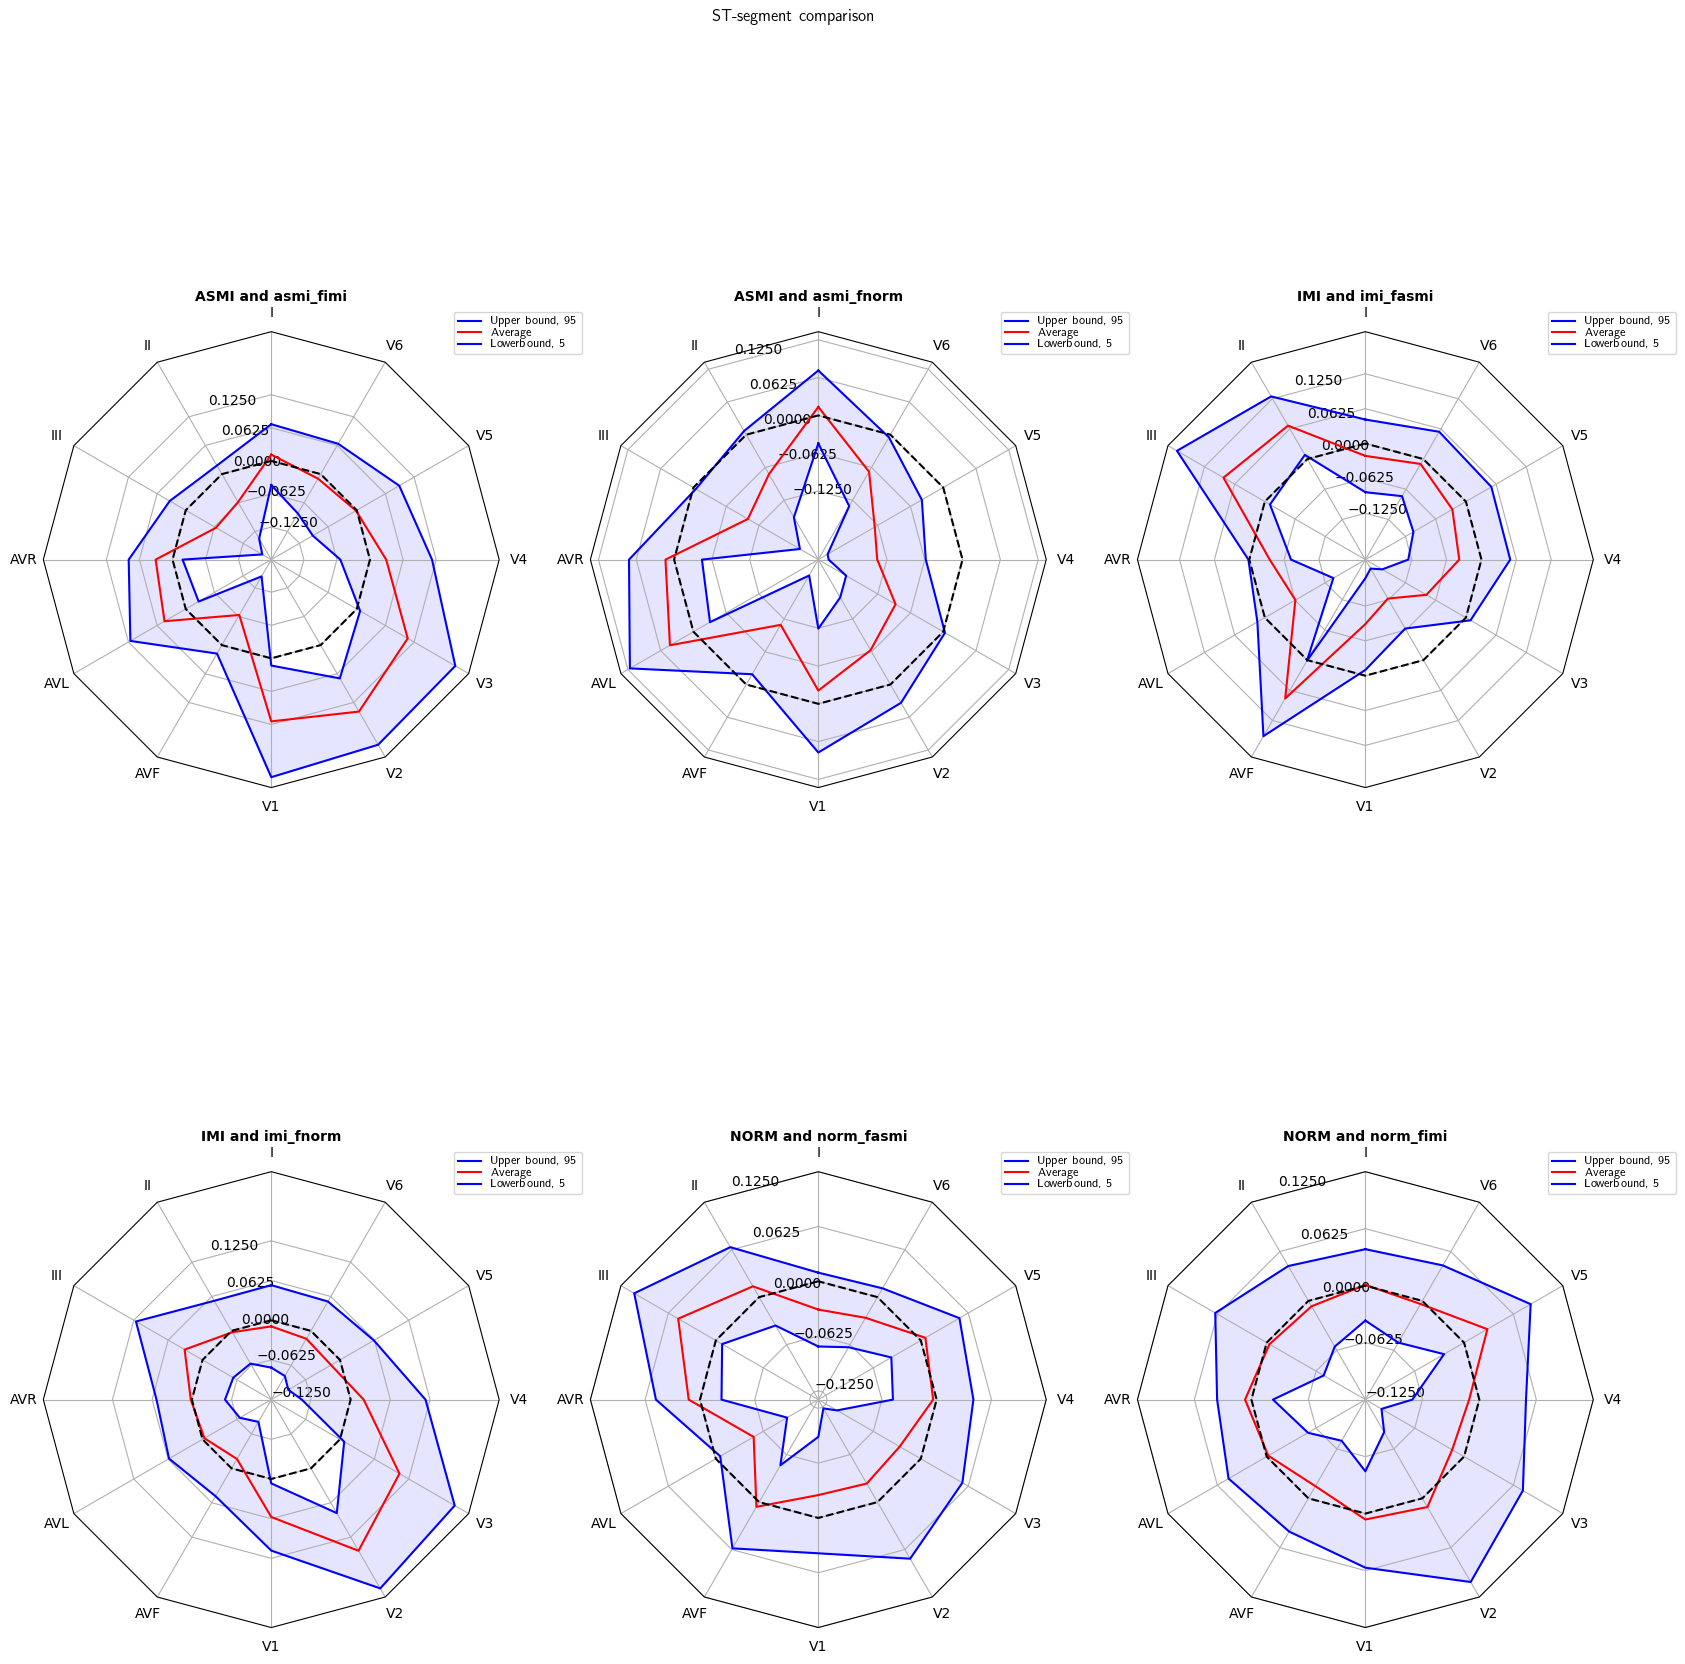

In [20]:
save_folder = "/home/ECG_Quality_Evaluation/Test_Figs"
plot_multiple_st_radar(ecg_datasets, st_start=13, st_end=21, fig_size=(20,20),
                       save_folder=save_folder, show_plot = True )